## Representation with Categorical Variables

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# https://dontpad.com/pucpr-ds2

df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/titanic.csv')

In [ ]:
df

# 891 linhas e 12 colunas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# vamos remover as colunas que
# não são úteis
# para a modelagem

df.drop(['PassengerId', 'Name',
         'Ticket', 'Cabin'],
        axis=1,
        inplace=True)

In [ ]:
df

# 891 linhas e 8 colunas

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
# precisamos transformar duas colunas
# categóricas em numéricas:
# Sex & Embarked

categorical_cols = ['Sex', 'Embarked']

In [ ]:
# vamos pegar também
# as demais colunas
other_cols = [
    x for x in df.columns if x not in categorical_cols
]
other_cols

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [ ]:
# 1) forma: OneHotEncoder
  # objetivo: transformar variáveis categóricas
  # em variáveis numéricas SEM INFERIOR ORDER

  # como isso é feito?
    # transformando cada categoria
    # em uma coluna binária (0/1)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# ohe = OneHotEncoder
# preprocessor_ohe = ColumnTransformer(
#     transformers=[
#         ('cat',
#          OneHotEncoder(sparse_output=False),
#          categorical_cols)
#     ],
#     remainder='passthrough'
# )

preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(sparse_output=False,
                       drop='first'),
         categorical_cols)
    ],
    remainder='passthrough'
)

# drop='first' evita multicolinearidade
# (por padrão, remoção da 1ª categoria).
  # multicolinearidade é um problema que
  # ocorre em modelos de regressão quando
  # duas ou mais variáveis independentes
  # estão altamente correlacionadas entre si.

In [ ]:
# vamos aplicar o transformador ao df
transformed = preprocessor_ohe.fit_transform(df)
transformed # retorna um numpy array

array([[ 1.    ,  0.    ,  1.    , ...,  1.    ,  0.    ,  7.25  ],
       [ 0.    ,  0.    ,  0.    , ...,  1.    ,  0.    , 71.2833],
       [ 0.    ,  0.    ,  1.    , ...,  0.    ,  0.    ,  7.925 ],
       ...,
       [ 0.    ,  0.    ,  1.    , ...,  1.    ,  2.    , 23.45  ],
       [ 1.    ,  0.    ,  0.    , ...,  0.    ,  0.    , 30.    ],
       [ 1.    ,  1.    ,  0.    , ...,  0.    ,  0.    ,  7.75  ]])

In [ ]:
# vamos definir nomes para
# as colunas geradas
encoded_feature_names = (
    preprocessor_ohe.named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)
encoded_feature_names

array(['Sex_male', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype=object)

In [ ]:
# vamos criar um DataFrame
df_ohe = pd.DataFrame(transformed,
                      columns=list(encoded_feature_names)
                      + other_cols)

print(df_ohe.shape) # 8 colunas -> 12 (ou 10 com drop=first)

df_ohe

# Vejam que o incremento no número de colunas
# poderia ser muito maior, especialmente se
# houver variáveis categóricas com muitas
# categorias distintas.

# Quando isso acontece,
# a matriz resultante pode ficar muito esparsa,
# ou seja, com muitos zeros,
# o que pode impactar desempenho e eficiência.

(891, 10)


,Sex_male,Embarked_Q,Embarked_S,Embarked_nan,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,1.0,0.0,0.0,3.0,22.0,1.0,0.0,7.2500
1,0.0,0.0,0.0,0.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,0.0,0.0,1.0,0.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,0.0,0.0,1.0,0.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,1.0,0.0,1.0,0.0,0.0,3.0,35.0,0.0,0.0,8.0500
...,...,...,...,...,...,...,...,...,...,...
886,1.0,0.0,1.0,0.0,0.0,2.0,27.0,0.0,0.0,13.0000
887,0.0,0.0,1.0,0.0,1.0,1.0,19.0,0.0,0.0,30.0000
888,0.0,0.0,1.0,0.0,0.0,3.0,NaN,1.0,2.0,23.4500
889,1.0,0.0,0.0,0.0,1.0,1.0,26.0,0.0,0.0,30.0000


In [ ]:
# 2a forma

# OrdinalEncoder
  # objetivo: transformar variáveis categóricas
  # em variáveis numéricas preservando uma ordem
  # implícita ou arbitrária.

  # como ele faz isso?
    # mapeia as categorias para inteiros
     # (0, 1, 2...)

from sklearn.preprocessing import OrdinalEncoder

preprocessor_oe = ColumnTransformer(
    transformers=[
        ('cat',
         OrdinalEncoder(),
         categorical_cols)
    ],
    remainder='passthrough'
)

In [ ]:
# aprender + aplicar a transformação
transformed = preprocessor_oe.fit_transform(df)

In [ ]:
# criar o DataFrame
df_oe = pd.DataFrame(transformed,
                     columns=list(categorical_cols)
                     + other_cols)
df_oe

,Sex,Embarked,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,2.0,0.0,3.0,22.0,1.0,0.0,7.2500
1,0.0,0.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,0.0,2.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,0.0,2.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,1.0,2.0,0.0,3.0,35.0,0.0,0.0,8.0500
...,...,...,...,...,...,...,...,...
886,1.0,2.0,0.0,2.0,27.0,0.0,0.0,13.0000
887,0.0,2.0,1.0,1.0,19.0,0.0,0.0,30.0000
888,0.0,2.0,0.0,3.0,NaN,1.0,2.0,23.4500
889,1.0,0.0,1.0,1.0,26.0,0.0,0.0,30.0000


In [ ]:
df.shape, df_oe.shape

# Diferente do OneHotEncoder,
# que aumenta a dimensionalidade do dataset,
# o OrdinalEncoder mantém o número de colunas original.

# Atenção: o OrdinalEncoder atribui números inteiros às categorias
# com base na ordem alfabética (ou ordem observada),
# o que pode induzir uma ordem artificial entre as classes
# e impactar negativamente modelos que consideram relações numéricas.

((891, 8), (891, 8))

## **PCA** (Continuation with MNIST)

In [ ]:
# carregar a base de dados

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784') # 20 seg +-

# mnist_784 -> versão clássica da MNIST
  # 28*28 = 784 pixels

In [ ]:
# transformar em DataFrame
df_mnist = pd.DataFrame(mnist.data)
df_mnist.head(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_mnist.shape

(70000, 784)

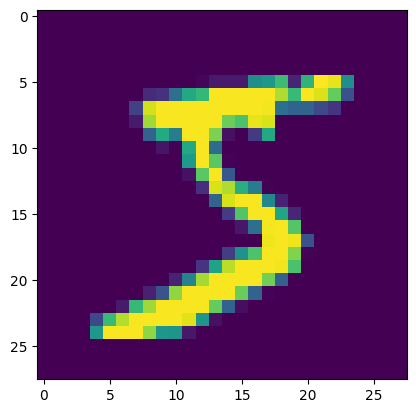

In [ ]:
# curiosidade -> mostrar uma imagem
plt.imshow(df_mnist.values[0].reshape(28, 28))

In [ ]:
# vamos adicionar no dataframe
# uma coluna target
df_mnist['TARGET'] = mnist.target
df_mnist.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,TARGET
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
df_mnist.shape

(70000, 785)

In [ ]:
# pra aula de hoje
# não precisamos de 70k amostras

# pegar 25% dos dados aleatoriamente
df_mnist_sample = df_mnist.sample(frac=0.25,
                                  random_state=123,
                                  ignore_index=True)

In [ ]:
df_mnist_sample.shape

(17500, 785)

In [ ]:
df_mnist_sample

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,TARGET
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
17496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
17497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
17498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
# vamos dividir em X e y
X = df_mnist_sample.drop('TARGET', axis=1)
y = df_mnist_sample['TARGET']

In [ ]:
# vamos dividir em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    stratify=y,
                                                    random_state=123)

In [ ]:
y_train.shape, y_test.shape

((8750,), (8750,))

In [ ]:
# Normalização
  # Etapa essencial antes de aplicar o PCA,
  # pois o PCA é sensível à escala das variáveis
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# StandardScaler:
  # transforma os dados para que cada feature (pixel)
  # tenha média 0 e desvio padrão 1

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # não faz o FIT

In [ ]:
# vamos treinar & avaliar um classificador

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000,
                        random_state=123)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

In [ ]:
# without PCA

y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(X_test.shape)
print(f'Accuracy = {100 * acc:.2f}% (without PCA)')

(8750, 784)
Accuracy = 87.94% (without PCA)


In [ ]:
# with PCA

from sklearn.decomposition import PCA

variance_retained_vals = [0.99, 0.95, 0.9, 0.5, 0.25]

print(f'variance: 1.00 | n_components: {X_test.shape[1]} (without PCA)')
print(f'    Accuracy = {100 * acc:.2f}%\n')

for variance in variance_retained_vals:
  # O PCA é determinístico em sua formulação original,
  # portanto não é necessário definir o random_state
  pca = PCA(variance)

  X_train_pca = pca.fit_transform(X_train)
  X_test_pca = pca.transform(X_test) # não faz o FIT

  print(f'variance: {variance} | n_components: {X_test_pca.shape[1]}')

  # training
  lr.fit(X_train_pca, y_train)

  # testing
  y_pred_pca = lr.predict(X_test_pca)

  acc_pca = accuracy_score(y_test, y_pred_pca)
  print(f'    Accuracy = {100 * acc_pca:.2f}%\n')

variance: 1.00 | n_components: 784 (without PCA)
    Accuracy = 87.94%

variance: 0.99 | n_components: 487
    Accuracy = 87.70%

variance: 0.95 | n_components: 281
    Accuracy = 88.46%

variance: 0.9 | n_components: 196
    Accuracy = 89.41%

variance: 0.5 | n_components: 33
    Accuracy = 88.43%

variance: 0.25 | n_components: 8
    Accuracy = 76.91%



In [ ]:
1920*1080

2073600

## **t-SNE**

In [ ]:
# carregar a MNIST
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784') # 20 seg +-

In [ ]:
# transformar em DataFrame
df_mnist = pd.DataFrame(mnist.data)
df_mnist.head(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_mnist['TARGET'] = mnist.target
df_mnist.shape

(70000, 785)

In [ ]:
# outra forma de amostragem
# 2500

df_mnist = df_mnist.loc[:2499]
df_mnist.shape

(2500, 785)

In [ ]:
# dividir em X e y
X = df_mnist.drop('TARGET', axis=1)
y = df_mnist['TARGET']

In [ ]:
# vamos aplicar o t-SNE

import seaborn as sns
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,
            max_iter=1000,
            random_state=123)

X_embedded = tsne.fit_transform(X) # 23 seg

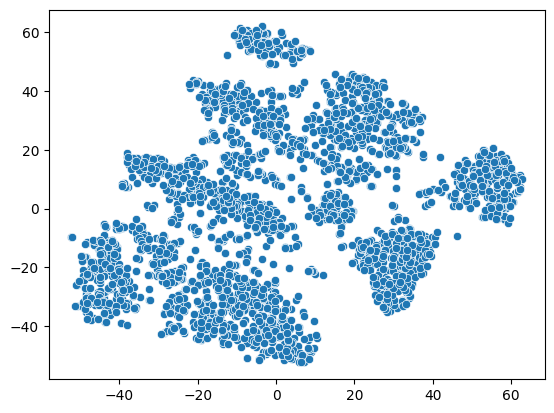

In [ ]:
# visualizar o resultado
sns.scatterplot(x=X_embedded[:, 0],
                y=X_embedded[:, 1])
plt.show()

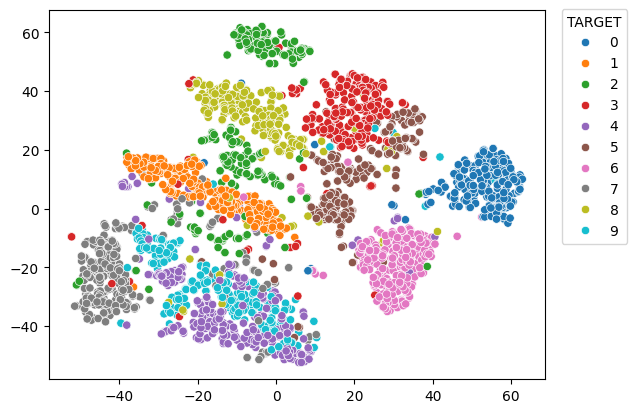

In [ ]:
# visualizar o resultado (com o target)
sns.scatterplot(x=X_embedded[:, 0],
                y=X_embedded[:, 1], hue=y)
plt.legend(title='TARGET', bbox_to_anchor=(1.02, 1.02))
plt.show()

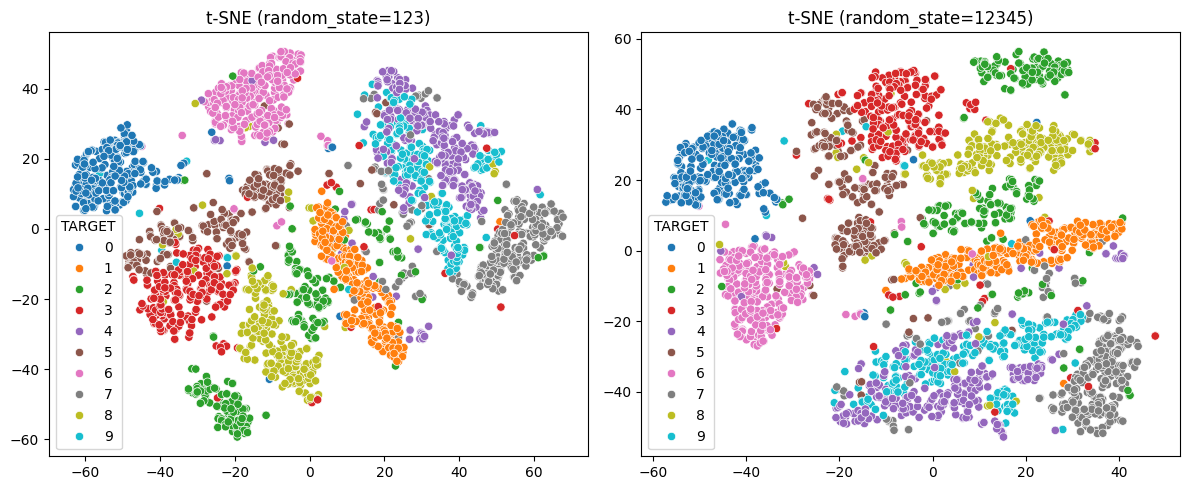

In [ ]:
# Criação de dois objetos t-SNE
# com diferentes random_state (semente aleatória)
  # Isso permite comparar o impacto
  # da aleatoriedade no resultado do t-SNE

tsne_1 = TSNE(n_components=2, init='random', random_state=123)
tsne_2 = TSNE(n_components=2, init='random', random_state=12345)
X_embedded1 = tsne_1.fit_transform(X)
X_embedded2 = tsne_2.fit_transform(X)

# Cria uma figura com dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primeiro gráfico: visualização do t-SNE com random_state=123
sns.scatterplot(x=X_embedded1[:, 0], y=X_embedded1[:, 1], ax=axes[0], hue=y)
axes[0].set_title("t-SNE (random_state=123)")

# Segundo gráfico: visualização do t-SNE com random_state=12345
sns.scatterplot(x=X_embedded2[:, 0], y=X_embedded2[:, 1], ax=axes[1], hue=y)
axes[1].set_title("t-SNE (random_state=12345)")

plt.tight_layout()
plt.show()

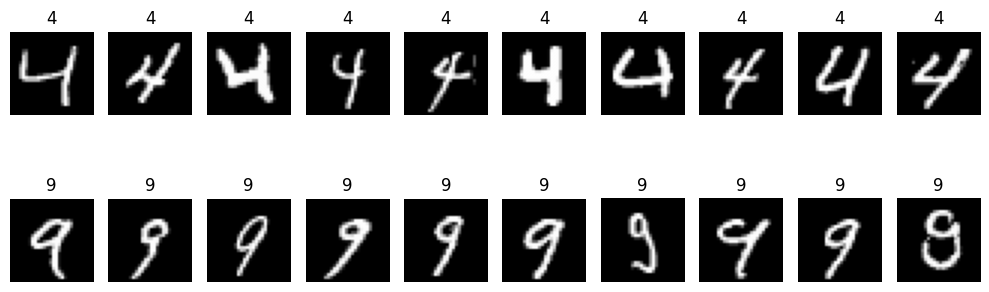

In [ ]:
# vou fazer um código para exibir alguns
# dígitos só por curiosidade

# Carrega o MNIST
mnist = fetch_openml('mnist_784', as_frame=False)
X = mnist['data']
y = mnist['target'].astype(int) # converte para inteiro

num_samples = 10

# Filtra os dígitos
digit_4_imgs = X[y == 4][:num_samples]
digit_9_imgs = X[y == 9][:num_samples]

# Plota
fig, axes = plt.subplots(2, num_samples, figsize=(10, 4))

for i in range(num_samples):
    axes[0, i].imshow(digit_4_imgs[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("4")

    axes[1, i].imshow(digit_9_imgs[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("9")

plt.tight_layout()
plt.show()

## Class Imbalance

In [ ]:
# https://dontpad.com/pucpr-ds2

df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/imbalanced.csv')

In [ ]:
df.head(3)

,attrib1,attrib2,attrib3,class
0,1.595781,5.540723,9.109505,groupA
1,2.657896,1.166703,1.368305,groupA
2,0.901466,4.374227,3.207844,groupA


<Axes: xlabel='attrib1', ylabel='attrib2'>

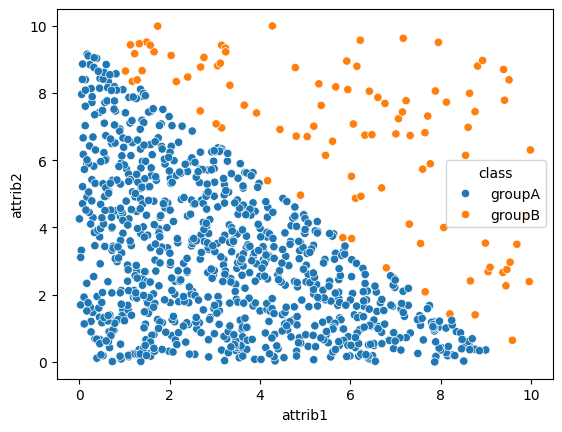

In [ ]:
sns.scatterplot(x=df['attrib1'],
                y=df['attrib2'],
                hue=df['class'])

In [ ]:
# separar o label dos dados
X = df.drop('class', axis=1)
y = df['class']

# dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, stratify=y, random_state=123
)


In [ ]:
# treinar um classificador

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# avaliar o modelo

y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'acc: {acc:.4f}')

acc: 0.9848


In [ ]:
# porcentagem de amostras por classe

class_dist = df['class'].value_counts(
    normalize=True
) * 100
class_dist

,proportion
class,
groupA,90.2
groupB,9.8


In [ ]:
# calcular outras métricas além
# da acurácia

from sklearn.metrics import f1_score

f1_a = f1_score(y_test, y_pred, pos_label='groupA')
f1_b = f1_score(y_test, y_pred, pos_label='groupB')
f1 = np.mean((f1_a, f1_b))

print(f'Accuracy: {acc:.4f}')
print(f'F1-Score: {f1:.4f}')

Accuracy: 0.9848
F1-Score: 0.9535


In [ ]:
# técnicas para lidar com
# desiquilibrio de classes

# OVERsampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# UNDERsampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import NearMiss

In [ ]:
# vamos criar um dicionário
# com as técnicas

samplers = {
    'RO': RandomOverSampler(random_state=123),
    'SMOTE': SMOTE(random_state=123),
    'RU': RandomUnderSampler(random_state=123),
    'NM1': NearMiss(version=1),
    'NM2': NearMiss(version=2),
    'NM3': NearMiss(version=3),
}

In [ ]:
# vamos aplicar cada técnica

for name, sampler in samplers.items():
  # aplicar o balanceamento no
  # conjunto de TREINO
  X_sampled, y_sampled = sampler.fit_resample(X_train,
                                              y_train)

  # treinar novamente o classificador
  # com os dados balanceados
  lr = LogisticRegression(max_iter=1000)
  lr.fit(X_sampled, y_sampled)

  # avaliar no MESMO conjunto de teste
  # que não foi balanceado
  # (para que a comparação seja justa)
  y_pred = lr.predict(X_test)

  # calculou as métricas
  acc = accuracy_score(y_test, y_pred)
  f1_a = f1_score(y_test, y_pred, pos_label='groupA')
  f1_b = f1_score(y_test, y_pred, pos_label='groupB')
  f1 = np.mean((f1_a, f1_b))

  print(f'{name}:\t acc: {acc:.4f} | f1: {f1:.4f}')

RO:	 acc: 0.9818 | f1: 0.9521
SMOTE:	 acc: 0.9939 | f1: 0.9832
RU:	 acc: 0.9970 | f1: 0.9912
NM1:	 acc: 0.9848 | f1: 0.9535
NM2:	 acc: 0.9879 | f1: 0.9633
NM3:	 acc: 0.9848 | f1: 0.9535


In [ ]:
# rodar N vezes
# e reportar a média

# vamos fazer só o f1
# por praticidade

dict_f1 = {'RO': [],
           'SMOTE': [],
           'RU': [],
           'NM1': [],
           'NM2': [],
           'NM3': []}

num_runs = 30
for idx_run in range(num_runs):
  print(f'run: {idx_run+1}')
  samplers = {'RO': RandomOverSampler(),
              'SMOTE': SMOTE(),
              'RU': RandomUnderSampler(),
              'NM1': NearMiss(version=1),
              'NM2': NearMiss(version=2),
              'NM3': NearMiss(version=3)}

  # para cada técnica:
  for name, sampler in samplers.items():
    # aplicar o balanceamento no CONJUNTO DE TREINO (fit_resample)
    X_sampled, y_sampled = sampler.fit_resample(X_train, y_train)

    # treinar novamente um modelo de regressão logística
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_sampled, y_sampled)

    # avaliar no MESMO conjunto de teste,
    # que não foi balanceado (importante para uma avaliação justa).
    y_pred = lr.predict(X_test)

    # acc = accuracy_score(y_test, y_pred)
    f1_a = f1_score(y_test, y_pred, pos_label='groupA')
    f1_b = f1_score(y_test, y_pred, pos_label='groupB')
    f1_ab = np.mean((f1_a, f1_b))

    # imprimir os resultados
    print(f"  {name + ':':6} {f1_ab:.4f}")
    dict_f1[name].append(f1_ab)

  print()

print(f'Mean Results ({num_runs} runs)')
for sampler in dict_f1:
  print(f"  {sampler + ':':6} {np.mean(dict_f1[sampler]):.4f} +- {np.std(dict_f1[sampler]):.4f}")

run: 1
  RO:    0.9672
  SMOTE: 0.9822
  RU:    0.9751
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 2
  RO:    0.9832
  SMOTE: 0.9912
  RU:    1.0000
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 3
  RO:    1.0000
  SMOTE: 0.9912
  RU:    0.9744
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 4
  RO:    0.9832
  SMOTE: 0.9912
  RU:    0.9822
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 5
  RO:    1.0000
  SMOTE: 0.9822
  RU:    0.9376
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 6
  RO:    0.9448
  SMOTE: 1.0000
  RU:    0.8691
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 7
  RO:    0.9832
  SMOTE: 0.9912
  RU:    0.8778
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 8
  RO:    0.9595
  SMOTE: 0.9912
  RU:    0.9595
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 9
  RO:    1.0000
  SMOTE: 0.9912
  RU:    0.9508
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 10
  RO:    0.9832
  SMOTE: 1.0000
  RU:    0.9173
  NM1:  